<a href="https://colab.research.google.com/github/HMS-Cleveland/Questionary_logist/blob/my/%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%92_%E9%99%84%E5%B8%A62%E4%B8%AA%E6%82%A3%E7%99%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 数据基本信息 ===
总样本数: 280660
9值已转为'unknown'类别
标签分布 - 阴性: 271355, 阳性: 9305
阳性率: 0.033

=== 数据分割结果 ===
训练集: 224530 样本, 阳性比例: 0.033
最优阈值: 0.100 (验证集灵敏度=0.994)
测试集AUC = 0.752

--- 6.1 Exact SHAP (M=9) ---
⚠️ 警告: Exact SHAP 运算量过大 (500x2^9xM 远超 10万)，已跳过！

--- 6.2 KernelSHAP ---


  0%|          | 0/500 [00:00<?, ?it/s]

KernelSHAP 耗时: 91.75 s

--- 6.3 k-additive SHAP (k=1, k=2) ---
  正在计算 k=1 SHAP...


k=1: 100%|████████████████████████████████████| 500/500 [03:10<00:00,  2.63it/s]


  正在计算 k=2 SHAP...


k=2: 100%|████████████████████████████████████| 500/500 [10:32<00:00,  1.27s/it]


k=1 SHAP 耗时: 197.70 s
k=2 SHAP 耗时: 654.33 s

--- SHAP 方法对比 ---
时间 (500 条): {'Kernel': 91.74567747116089, 'k=1': 197.69762873649597, 'k=2': 654.3301949501038}

全局重要性 (按方法):
                              Kernel      k=1      k=2
menopause                   0.03063  0.00329  0.00656
age_5_years                 0.04034  0.00440  0.00877
BIRADS_breast_density       0.05894  0.00654  0.01302
ethnic                      0.11911  0.01370  0.02723
bmi                         0.05447  0.00579  0.01147
first_birth                 0.06562  0.00616  0.01231
num_of_first_degree_cancer  0.07029  0.00784  0.01560
breast_surgery              0.04445  0.00505  0.01003
hormone_therapy             0.02802  0.00282  0.00555

两两 MAE:
          Kernel      k=1      k=2
Kernel  0.00000  0.05101  0.04513
k=1     0.05101  0.00000  0.00611
k=2     0.04513  0.00611  0.00000


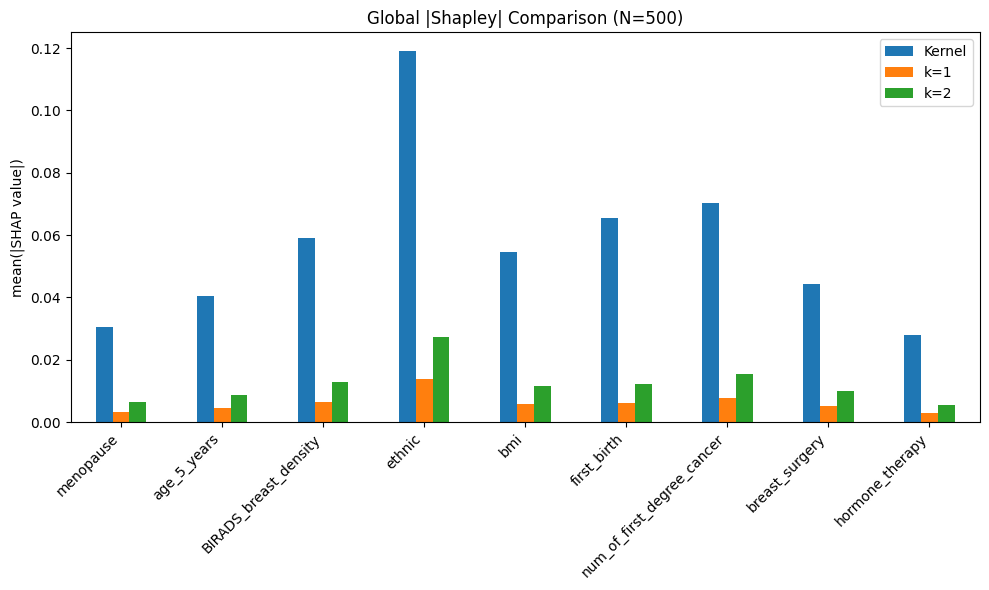


=== SHAP 汇总图 ===


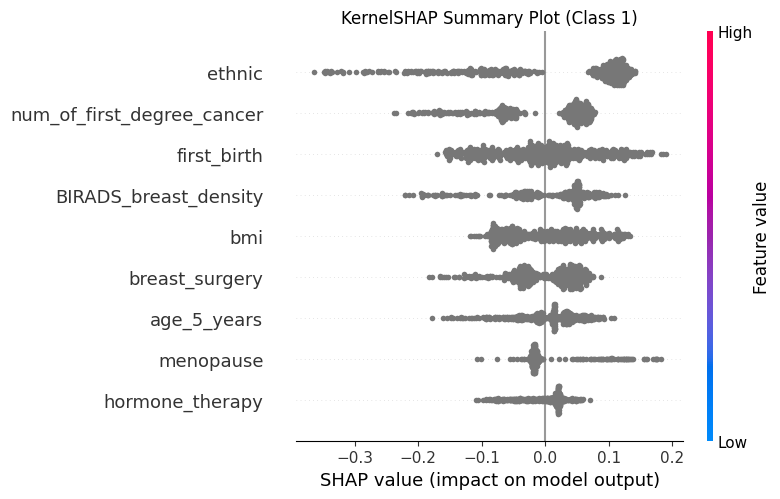

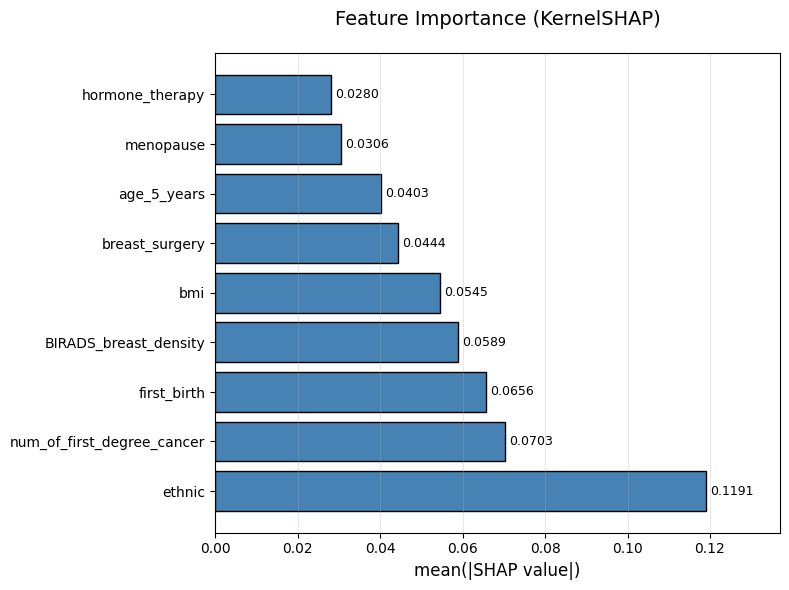


--- SHAP 依赖图 - num_of_first_degree_cancer ---


/tmp/ipython-input-1106121084.py:384: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1106121084.py:384: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1106121084.py:384: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1106121084.py:384: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

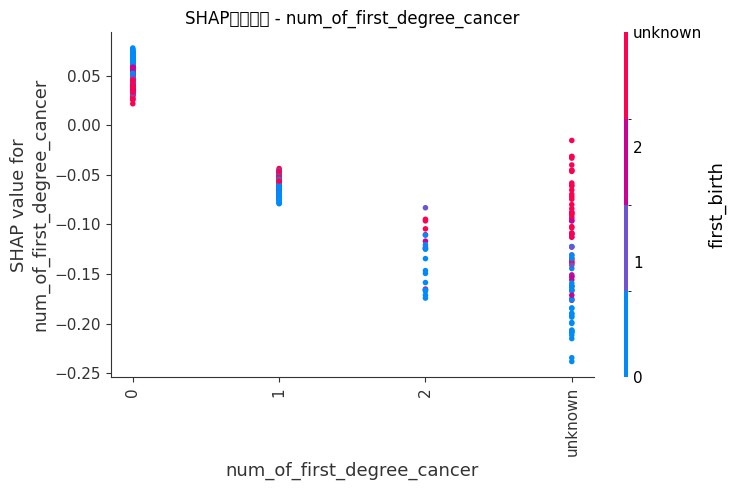

In [2]:
# =============== 0. 依赖安装（确保所有库已安装） ===============
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE # 确保安装了 imblearn
import matplotlib.pyplot as plt
import shap
import time
from itertools import combinations
from math import factorial
from joblib import Parallel, delayed
from tqdm import tqdm
# ------------------------------------------------------------------


# ------------------------------------------------------------------
# 1. 非线性逻辑回归模型训练
# ------------------------------------------------------------------
# 1. 数据加载与预处理
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

# 假设文件路径已在 Colab 环境中存在
FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'
data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)

# 精细化缺失值处理：年龄分层的9保留，其他特征的9替换为'unknown'
print("=== 数据基本信息 ===")
print(f"总样本数: {len(data)}")

cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']

data_processed = data.copy()
for col in cols_with_missing_9:
    data_processed[col] = data_processed[col].replace(9, 'unknown').astype(str)
# 确保所有分类特征都为字符串
data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)

print("9值已转为'unknown'类别")

# 构造标签
data_processed['diagnosis'] = (data_processed['diagnosis_12'] | data_processed['diagnosis_13']).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

print(f"标签分布 - 阴性: {sum(data_processed['diagnosis'] == 0)}, 阳性: {sum(data_processed['diagnosis'] == 1)}")
print(f"阳性率: {data_processed['diagnosis'].mean():.3f}")

# ------------------------------------------------------------------
# 2. 特征工程与数据分割
# ------------------------------------------------------------------

X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']

# 分层分割数据
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42
)

X_train_res = X_train
y_train_res = y_train

print(f"\n=== 数据分割结果 ===")
print(f"训练集: {X_train.shape[0]} 样本, 阳性比例: {y_train.mean():.3f}")

# ------------------------------------------------------------------
# 3. 改进的特征预处理管道
# ------------------------------------------------------------------

# 定义特征类型
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']

preprocessor = ColumnTransformer(
    transformers=[
        # 有序分类
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        # 无序分类
        ('nominal', OneHotEncoder(handle_unknown='ignore', drop=None), nominal_features),
        # 二分类
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features),
    ],
    remainder='passthrough'
)

# 构造完整的 Pipeline
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        penalty='l2', C=0.008, solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=42
    ))
])

# 5. 训练模型
model_pipeline.fit(X_train_res, y_train_res)

# 6. 阈值优化（最大化灵敏度）- 略过详细输出
val_probs = model_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.1, 1, 50)
best_recall = 0
best_thresh = 0.5
for thresh in thresholds:
    y_val_pred = (val_probs > thresh).astype(int)
    recall = recall_score(y_val, y_val_pred)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"最优阈值: {best_thresh:.3f} (验证集灵敏度={best_recall:.3f})")

# 7. 测试集评估 - 略过详细输出
test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_pred_optim = (test_probs > 0.4).astype(int)

print(f"测试集AUC = {roc_auc_score(y_test, test_probs):.3f}")

# ------------------------------------------------------------------
# 4. SHAP 计算设置
# ------------------------------------------------------------------

# 0. 统一背景 & 全局样本池
N_SHAP_SAMPLE = 500 # 样本数量
# 背景样本用于估算 E[f(x)]。对于 Pipeline，背景样本也必须是原始 DataFrame 格式
COMMON_BG = X_train_res.sample(500, random_state=42)
# X_global 是要解释的样本，也必须是原始 DataFrame 格式
X_global = X_test.sample(N_SHAP_SAMPLE, random_state=123)

features = X.columns
M = X.shape[1]

# 定义预测函数：接收DataFrame，直接走pipeline的预测
def pred_fn_full_pipeline(X_input):
    """
    X_input: 原始特征格式 (pd.DataFrame).
    返回: 模型预测的概率 (Class 1)
    """
    # 确保 X_input 是 DataFrame 且列名正确
    if isinstance(X_input, np.ndarray):
        X_input_df = pd.DataFrame(X_input, columns=X.columns)
    else:
        X_input_df = X_input

    # 我们将在概率空间上进行 SHAP 计算 (0到1)
    return model_pipeline.predict_proba(X_input_df)[:, 1]

# ------------------------------------------------------------------
# 5. Exact/K-additive SHAP 函数 (基于原始 DataFrame 格式)
# ------------------------------------------------------------------

# 注意：自定义 SHAP 需要使用原始数据（DataFrame）进行掩码操作，以保证 Pipeline
# 的 ColumnTransformer 步骤能够正确执行。

def exact_shap_one(xser: pd.Series):
    """
    xser: pd.Series, 单个待解释样本 (原始特征格式)
    返回: 长度 M 的 numpy 数组，Exact SHAP 值
    """
    phis = np.zeros(M)
    x_val = xser.values

    # Background DataFrame 方便掩码
    bg_df = COMMON_BG.copy()

    for i in range(M):
        for size in range(0, M):
            other_features_indices = [j for j in range(M) if j != i]

            for S_indices in combinations(other_features_indices, size):
                S_cols = [features[j] for j in S_indices]
                i_col = features[i]

                weight = factorial(len(S_cols)) * factorial(M - len(S_cols) - 1) / factorial(M)

                # --- 构造 X_S (i缺席) vs X_Si (i出席) ---
                X_S = bg_df.copy()
                X_Si = bg_df.copy()

                # 替换 S 集合中的特征为 x 的值
                for col in S_cols:
                    X_S[col] = xser[col]
                    X_Si[col] = xser[col]

                # 替换 i 特征的值（仅 X_Si）
                X_Si[i_col] = xser[i_col]

                # 预测并计算边际贡献
                f_S = pred_fn_full_pipeline(X_S).mean()
                f_Si = pred_fn_full_pipeline(X_Si).mean()

                phis[i] += weight * (f_Si - f_S)
    return phis

def k_additive_shap_one(xser: pd.Series, k: int = 2):
    """
    计算 k-additive 限制下的 SHAP 值 (基于原始特征格式的 Pipeline)
    该方法仅对 |S| < k 的子集求和。
    """
    phis = np.zeros(M)
    x_val = xser.values

    bg_df = COMMON_BG.copy()

    for i in range(M):
        max_size = min(k - 1, M - 1)

        for size in range(0, max_size + 1):
            other_features_indices = [j for j in range(M) if j != i]

            for S_indices in combinations(other_features_indices, size):
                S_cols = [features[j] for j in S_indices]
                i_col = features[i]

                # 标准 SHAP 权重
                weight = factorial(len(S_cols)) * factorial(M - len(S_cols) - 1) / factorial(M)

                # --- 构造 X_S (i缺席) vs X_Si (i出席) ---
                X_S = bg_df.copy()
                X_Si = bg_df.copy()

                # 替换 S 集合中的特征为 x 的值
                for col in S_cols:
                    X_S[col] = xser[col]
                    X_Si[col] = xser[col]

                # 替换 i 特征的值（仅 X_Si）
                X_Si[i_col] = xser[i_col]

                # 预测并计算边际贡献
                f_S = pred_fn_full_pipeline(X_S).mean()
                f_Si = pred_fn_full_pipeline(X_Si).mean()

                phis[i] += weight * (f_Si - f_S)
    return phis

def compute_custom_shap(X_sample: pd.DataFrame, method: str, k: int = None):
    """
    根据方法名称调用相应的自定义 SHAP 函数，并使用并行计算。
    """
    if method == 'Exact':
        func = exact_shap_one
    elif method == 'k=1':
        func = lambda x: k_additive_shap_one(x, k=1)
    elif method == 'k=2':
        func = lambda x: k_additive_shap_one(x, k=2)
    else:
        raise ValueError("Invalid custom method")

    print(f"  正在计算 {method} SHAP...")
    start_k = time.time()

    shap_vals = np.array(
        Parallel(n_jobs=8)(delayed(func)(X_sample.iloc[i])
                            for i in tqdm(range(len(X_sample)), desc=method, ncols=80))
    )

    times[method] = time.time() - start_k
    return shap_vals

# ------------------------------------------------------------------
# 6. SHAP 计算与对比
# ------------------------------------------------------------------
times, shapley_mat = {}, {}

# 1. Exact SHAP
# 注意：M=9, 2^9 = 512。N_SHAP_SAMPLE=500, 总预测次数约 500*512*9*500 = 11.5亿次。
# 必须使用小样本数 (N_SHAP_SAMPLE < 5) 才能运行 Exact SHAP。
if N_SHAP_SAMPLE * 2**M > 100000:
    print(f"\n--- 6.1 Exact SHAP (M={M}) ---")
    print(f"⚠️ 警告: Exact SHAP 运算量过大 ({N_SHAP_SAMPLE}x2^{M}xM 远超 10万)，已跳过！")
    # 为了后续对比，我们跳过 Exact SHAP 的计算
else:
    shapley_mat['Exact'] = compute_custom_shap(X_global, 'Exact')


# 2. KernelSHAP (用于与 k-add 对比)
print("\n--- 6.2 KernelSHAP ---")
start = time.time()
# KernelSHAP 背景数据使用 pd.DataFrame
explainer = shap.KernelExplainer(pred_fn_full_pipeline, COMMON_BG, link='identity')
shapley_mat['Kernel'] = explainer.shap_values(X_global, nsamples=64)
times['Kernel'] = time.time() - start
print(f"KernelSHAP 耗时: {times['Kernel']:.2f} s")


# 3. k-additive SHAP (k=1, k=2)
print("\n--- 6.3 k-additive SHAP (k=1, k=2) ---")
# 注意：k=1, k=2 运算量也大，但远小于 Exact
shapley_mat['k=1'] = compute_custom_shap(X_global, 'k=1')
shapley_mat['k=2'] = compute_custom_shap(X_global, 'k=2')

print(f"k=1 SHAP 耗时: {times['k=1']:.2f} s")
print(f"k=2 SHAP 耗时: {times['k=2']:.2f} s")


# 4. 结果对比
all_methods = [m for m in ['Kernel', 'k=1', 'k=2'] if m in shapley_mat]
global_imp = {k: np.abs(v).mean(0) for k, v in shapley_mat.items()}
df_global = pd.DataFrame(global_imp, index=features)
mae_tab = pd.DataFrame({m1: {m2: np.abs(shapley_mat[m1] - shapley_mat[m2]).mean()
                             for m2 in all_methods} for m1 in all_methods})


print('\n--- SHAP 方法对比 ---')
print('时间 ({} 条):'.format(N_SHAP_SAMPLE), times)
print('\n全局重要性 (按方法):\n', df_global.round(5))
print('\n两两 MAE:\n', mae_tab.astype(float).round(5))

# 全局重要性柱状图对比
df_global.plot(kind='bar', figsize=(10, 6))
plt.title(f'Global |Shapley| Comparison (N={N_SHAP_SAMPLE})')
plt.ylabel('mean(|SHAP value|)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 7. 可视化 (使用 KernelSHAP 结果作为基准)
# ------------------------------------------------------------------
sv_k_matrix = shapley_mat['Kernel']

# --- Summary Plot ---
# (为了着色)
# 这里使用 X_global 原始数据，但由于 KernelSHAP 不要求数值化，SHAP 库会自动处理
print("\n=== SHAP 汇总图 ===")
shap.summary_plot(
    shap_values=sv_k_matrix,
    features=X_global,
    feature_names=X_global.columns.tolist(),
    plot_type="dot",
    show=False
)
plt.title("KernelSHAP Summary Plot (Class 1)")
plt.tight_layout()
plt.show()

# --- Feature Importance Bar Chart ---
global_imp = np.abs(sv_k_matrix).mean(axis=0)
sorted_idx = np.argsort(global_imp)[::-1]
sorted_features = [features[i] for i in sorted_idx]
sorted_values = global_imp[sorted_idx]

plt.figure(figsize=(8, 6))
bars = plt.barh(sorted_features, sorted_values, color='steelblue', edgecolor='black')

for i, (bar, value) in enumerate(zip(bars, sorted_values)):
    plt.text(value + 0.001, i, f'{value:.4f}', va='center', ha='left', fontsize=9, color='black')

plt.xlim(0, sorted_values.max() * 1.15)
plt.xlabel('mean(|SHAP value|)', fontsize=12)
plt.title('Feature Importance (KernelSHAP)', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Dependence Plot ---
feature_name = 'num_of_first_degree_cancer'
feature_index = X.columns.get_loc(feature_name)

print(f"\n--- SHAP 依赖图 - {feature_name} ---")
shap.dependence_plot(
    feature_index,
    sv_k_matrix,
    X_global, # 使用原始 DataFrame
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP值散点图 - {feature_name}")
plt.tight_layout()
plt.show()


# # 目标模型：PolynomialFeatures -> StandardScaler -> LogisticRegression
# model_for_pdp = Pipeline([
#      ('poly', model_pipeline['poly']),
#      ('scaler', model_pipeline['scaler']),
#      ('logreg', model_pipeline['logreg'])
# ])

# feature_name_pdp = 'num_of_first_degree_cancer'

# PartialDependenceDisplay.from_estimator(
#     model_for_pdp, # 只包含后半段的模型
#     X_train_encoded_df,  # 数值化的训练集 (必须使用 OrdinalEncoder 后的数值)
#     features=[feature_name_pdp],
#     kind='average',
#     subsample=1000, random_state=42,
#     grid_resolution=20
# )
# plt.suptitle(f'PDP: {feature_name_pdp} → 预测风险（主效应）', fontsize=14)
# plt.tight_layout()
# plt.show()

12和13关系诊断报告

1. 交叉表（行=12，列=13）：
        13=0  13=1      总计
12=0  271355  2114  273469
12=1       0  7191    7191
总计    271355  9305  280660

2. 关键诊断指标：
   - 样本总数: 280660
   - 13=1的样本数: 9305
   - 12=1的样本数: 7191
   - ❗ 包含率 (13=1 → 12=1): 77.3%

3. 关系自动诊断：
   ❌ 部分重叠关系（包含率=77.3%）
   解释：两变量相关但独立

4. 关键证据样本（13=1但12=0，共2114个）：
      age_5_years  num_of_first_degree_cancer  BIRADS_breast_density
832             1                           1                      2
1993            1                           0                      3
2257            1                           0                      3


/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missi

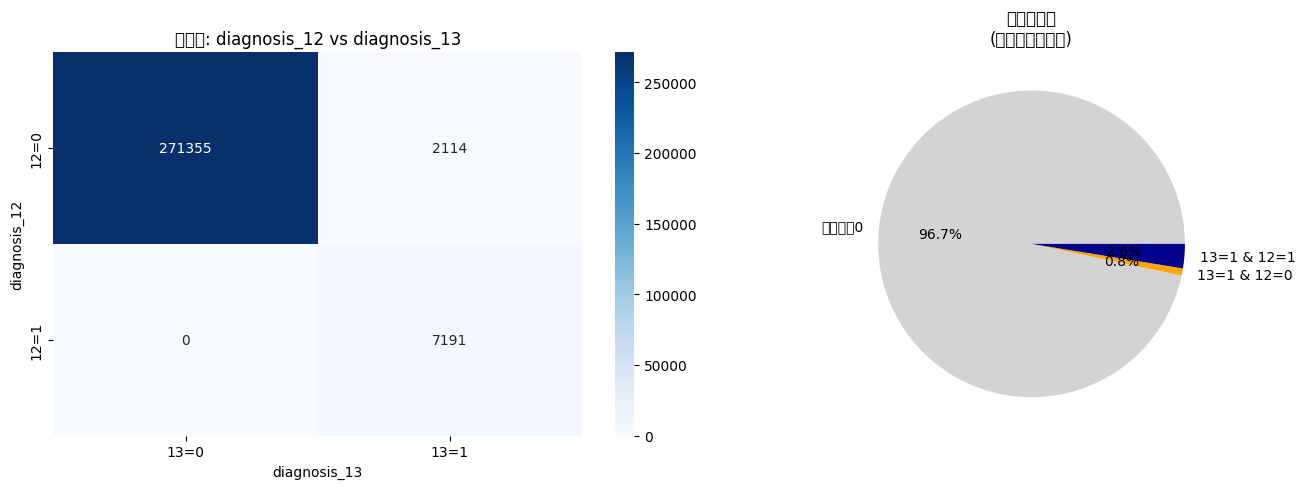


最终决策建议
❌ 数据问题：12和13不是包含关系，需重新定义数据字典


In [ ]:
# ==================== 诊断12和13关系的完整代码 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取原始数据（不处理标签，保留原始状态）
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)

print("="*60)
print("12和13关系诊断报告")
print("="*60)

# 2. 构建核心诊断工具：交叉表
cross_tab = pd.crosstab(
    data['diagnosis_12'],
    data['diagnosis_13'],
    margins=True,
    margins_name='总计'
)
cross_tab.index = ['12=0', '12=1', '总计']
cross_tab.columns = ['13=0', '13=1', '总计']
print("\n1. 交叉表（行=12，列=13）：")
print(cross_tab)

# 3. 计算关键指标：包含率和互斥率
total_samples = len(data)
cancer_13 = data['diagnosis_13'] == 1
cancer_12 = data['diagnosis_12'] == 1

# 黄金指标：当13=1时，12也=1的比例
containment_rate = (cancer_13 & cancer_12).sum() / cancer_13.sum()
print(f"\n2. 关键诊断指标：")
print(f"   - 样本总数: {total_samples}")
print(f"   - 13=1的样本数: {cancer_13.sum()}")
print(f"   - 12=1的样本数: {cancer_12.sum()}")
print(f"   - ❗ 包含率 (13=1 → 12=1): {containment_rate:.1%}")

# 4. 自动判断关系类型
print(f"\n3. 关系自动诊断：")
if containment_rate == 1.0:
    print("   ✅ 完全包含关系")
    print("   解释：13是12的超集（13包含12）")
    print("   建议：13=浸润性癌+DCIS, 12=仅浸润性癌")
elif containment_rate > 0.95:
    print(f"   ⚠️ 近似包含关系（包含率={containment_rate:.1%}）")
    print("   建议：检查剩余{cancer_13.sum() - (cancer_13 & cancer_12).sum()}个样本是否为数据错误")
elif containment_rate > 0.5:
    print(f"   ❌ 部分重叠关系（包含率={containment_rate:.1%}）")
    print("   解释：两变量相关但独立")
else:
    print(f"   ❌ 无包含关系（包含率={containment_rate:.1%}）")
    print("   解释：12和13是独立变量")

# 5. 证据性样本抽查（如果存在互斥样本）
mutual_exclusion = (cancer_13 & ~cancer_12)
if mutual_exclusion.sum() > 0:
    print(f"\n4. 关键证据样本（13=1但12=0，共{mutual_exclusion.sum()}个）：")
    examples = data[mutual_exclusion].head(3)
    print(examples[['age_5_years', 'num_of_first_degree_cancer', 'BIRADS_breast_density']])
else:
    print(f"\n4. 关键证据：不存在13=1且12=0的样本")

# 6. 可视化关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6.1 交叉表热力图
sns.heatmap(cross_tab.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('交叉表: diagnosis_12 vs diagnosis_13')
axes[0].set_xlabel('diagnosis_13')
axes[0].set_ylabel('diagnosis_12')

# 6.2 包含关系示意图
labels = ['两者都为0', '13=1 & 12=0', '13=1 & 12=1']
sizes = [
    (~cancer_13 & ~cancer_12).sum(),
    mutual_exclusion.sum(),
    (cancer_13 & cancer_12).sum()
]
colors = ['lightgray', 'orange', 'darkblue']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('关系示意图\n(橙色区域是关键)')

plt.tight_layout()
plt.show()

# 7. 最终决策建议
print("\n" + "="*60)
print("最终决策建议")
print("="*60)
if containment_rate == 1.0:
    decision = "✅ 采用方案：13=患癌（总标签），12=浸润性癌（亚型）"
    print(decision)
    print("   后续分析：在患癌人群中，用12区分浸润性癌和DCIS")
elif containment_rate > 0.95:
    print("⚠️ 需人工核查例外样本后，再决定标签定义")
else:
    print("❌ 数据问题：12和13不是包含关系，需重新定义数据字典")